In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import glob
import os

# get the csv files from google drive
path = '/content/drive/MyDrive/Cyclistic_Data'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Columns we actually need
columns_to_keep = [
    'ride_id', 'rideable_type', 'started_at', 'ended_at',
    'start_station_name', 'end_station_name', 'member_casual'
]

optimized_list = []

print("Starting cloud-optimized file processing...")


for filename in all_files:
    print(f"Processing: {os.path.basename(filename)}")
    df = pd.read_csv(filename, usecols=columns_to_keep)

    # Convert text columns to 'category' types to save massive memory space
    df['member_casual'] = df['member_casual'].astype('category')
    df['rideable_type'] = df['rideable_type'].astype('category')

    optimized_list.append(df)

# 3. Combine everything into one giant table stacked vertically
print("\nMerging all files into a master dataset...")
all_trips = pd.concat(optimized_list, ignore_index=True)

print("\n--- ONLINE MERGE SUCCESSFUL ---")
print(f"Total Rows Combined: {all_trips.shape[0]:,}")
print(f"Total Columns Kept: {all_trips.shape[1]}")

Starting cloud-optimized file processing...
Processing: 202604-divvy-tripdata.csv
Processing: 202505-divvy-tripdata.csv
Processing: 202603-divvy-tripdata.csv
Processing: 202602-divvy-tripdata.csv
Processing: 202506-divvy-tripdata.csv
Processing: 202507-divvy-tripdata.csv
Processing: 202508-divvy-tripdata.csv
Processing: 202509-divvy-tripdata.csv
Processing: 202510-divvy-tripdata.csv
Processing: 202511-divvy-tripdata.csv
Processing: 202512-divvy-tripdata.csv
Processing: 202601-divvy-tripdata.csv

Merging all files into a master dataset...

--- ONLINE MERGE SUCCESSFUL ---
Total Rows Combined: 5,697,455
Total Columns Kept: 7


In [3]:
# Convert 'started_at' and 'ended_at' columns to datetime objects
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])

# Confirming the data type
print(all_trips[['started_at', 'ended_at']].dtypes)

started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


In [4]:
# 1. Calculate ride length in minutes
all_trips['ride_length'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds() / 60

# 2. Extract the day of the week (1=Monday, 2=Tuesday, ..., 7=Sunday)
all_trips['day_of_week'] = all_trips['started_at'].dt.isocalendar().day

all_trips[['started_at', 'ended_at', 'ride_length', 'day_of_week']].head()

,started_at,ended_at,ride_length,day_of_week
0,2026-04-13 14:47:32.170,2026-04-13 14:48:57.868,1.428300,1
1,2026-04-13 09:56:56.062,2026-04-13 10:24:12.047,27.266417,1
2,2026-04-13 08:33:39.927,2026-04-13 08:55:36.991,21.951067,1
3,2026-04-13 12:04:56.051,2026-04-13 12:31:00.820,26.079483,1
4,2026-04-26 08:50:42.378,2026-04-26 08:56:44.514,6.035600,7


In [5]:
# Find out how many rows have a ride length of 0 or negative minutes
bad_rows = all_trips[all_trips['ride_length'] <= 0].shape[0]
print(f"Number of rows with invalid/negative trip durations: {bad_rows:,}")

# Keep only the rows where ride_length is greater than 0
all_trips_clean = all_trips[all_trips['ride_length'] > 0].copy()

print(f"New cleaned row count: {all_trips_clean.shape[0]:,}")

Number of rows with invalid/negative trip durations: 29
New cleaned row count: 5,697,426


In [6]:
import numpy as np

print("DESCRIPTIVE ANALYSIS")

# 1. Overall Comparison: Calculate mean and max ride lengths grouped by user type
overall_stats = all_trips_clean.groupby('member_casual')['ride_length'].agg(['mean', 'max']).reset_index()
print("\nOverall Ride Length Statistics (in Minutes):")
print(overall_stats)

# 2. Analyze by Day of the Week: Calculate average duration and total number of rides
weekly_analysis = all_trips_clean.groupby(['member_casual', 'day_of_week']).agg(
    average_ride_length=('ride_length', 'mean'),
    number_of_rides=('ride_id', 'count')
).reset_index()

# Sort the results chronologically by day of the week (1=Monday to 7=Sunday)
weekly_analysis = weekly_analysis.sort_values(by=['member_casual', 'day_of_week'])

print("\nRide Statistics by Day of the Week (1=Monday, 7=Sunday):")
print(weekly_analysis)

--- DESCRIPTIVE ANALYSIS ---

Overall Ride Length Statistics (in Minutes):
  member_casual       mean          max
0        casual  22.448311  1574.900183
1        member  12.435649  1559.903683


/tmp/ipykernel_6768/1430995598.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_stats = all_trips_clean.groupby('member_casual')['ride_length'].agg(['mean', 'max']).reset_index()
/tmp/ipykernel_6768/1430995598.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_analysis = all_trips_clean.groupby(['member_casual', 'day_of_week']).agg(



Ride Statistics by Day of the Week (1=Monday, 7=Sunday):
   member_casual  day_of_week  average_ride_length  number_of_rides
0         casual            1            22.289555           232913
1         casual            2            19.504655           229268
2         casual            3            18.801959           229446
3         casual            4            19.845355           268851
4         casual            5            22.238593           320542
5         casual            6            25.137545           416578
6         casual            7            25.961811           340190
7         member            1            12.098686           513977
8         member            2            12.008451           580962
9         member            3            11.915223           578335
10        member            4            12.008096           602097
11        member            5            12.373106           538796
12        member            6            13.615561        

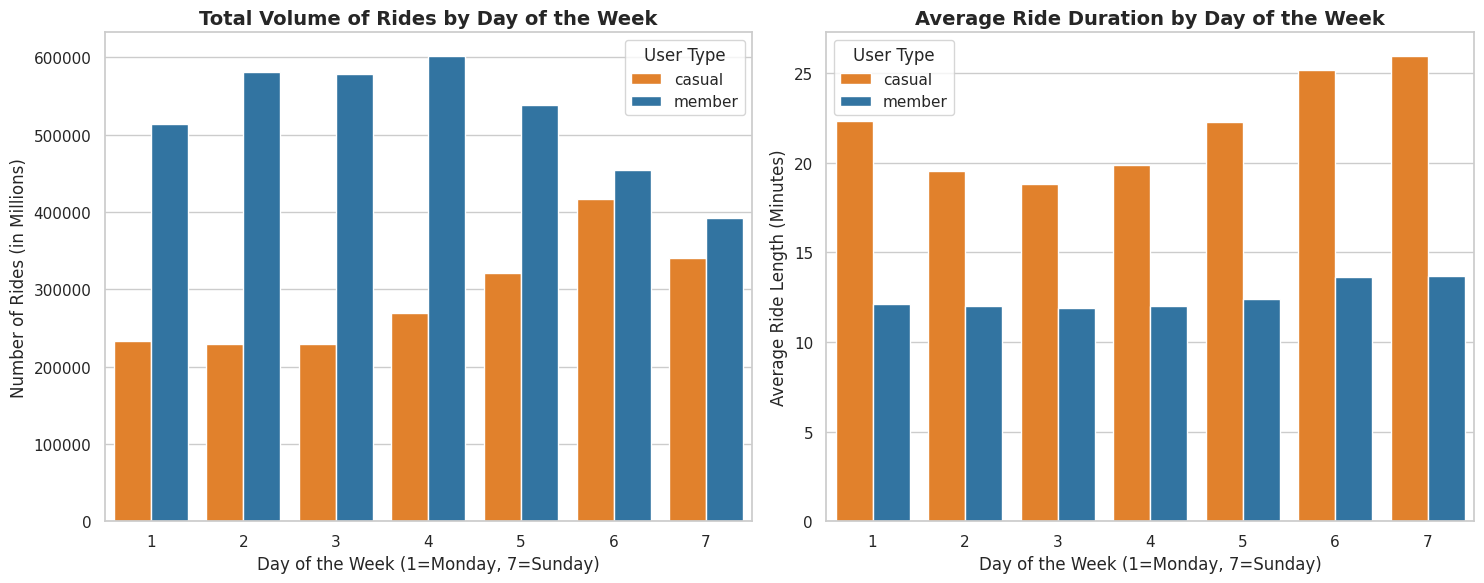

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean style for our plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# --- CHART 1: Total Volume of Rides by Day of the Week ---
plt.subplot(1, 2, 1) # Create the left-side chart space
sns.barplot(
    data=weekly_analysis,
    x='day_of_week',
    y='number_of_rides',
    hue='member_casual',
    palette=['#FF7F0E', '#1F77B4'] # Bright contrast colors
)
plt.title('Total Volume of Rides by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)', fontsize=12)
plt.ylabel('Number of Rides (in Millions)', fontsize=12)
plt.legend(title='User Type')

# --- CHART 2: Average Ride Duration by Day of the Week ---
plt.subplot(1, 2, 2) # Create the right-side chart space
sns.barplot(
    data=weekly_analysis,
    x='day_of_week',
    y='average_ride_length',
    hue='member_casual',
    palette=['#FF7F0E', '#1F77B4']
)
plt.title('Average Ride Duration by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)', fontsize=12)
plt.ylabel('Average Ride Length (Minutes)', fontsize=12)
plt.legend(title='User Type')

# Optimize layout spacing and render the charts
plt.tight_layout()
plt.show()

In [8]:
# Saving the final dataset
output_path = '/content/drive/MyDrive/Cyclistic_Data/cyclistic_final_clean_data.csv'

print("Saving your cleaned dataset to Google Drive")
all_trips_clean.to_csv(output_path, index=False)
print("Saved")

Saving your cleaned dataset to Google Drive... This may take a minute...
Saved successfully! You are officially finished with the data pipeline.
